In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

from imblearn.over_sampling import SMOTE

In [3]:
# Load Dataset
data = pd.read_csv("Baza customer Telecom v2.csv")

print(data.head())
print(data.shape)
print(data.info())

         PID CRM_PID_Value_Segment EffectiveSegment  Billing_ZIP KA_name  \
0  123759242                Bronze             SOHO       6000.0      VM   
1  126145737                Bronze             SOHO       6400.0      VM   
2  123506355                Bronze             SOHO       6000.0      DI   
3  112595585                Bronze             SOHO       4400.0      MT   
4  115097935                  Iron             SOHO       4000.0      AD   

   Active_subscribers  Not_Active_subscribers  Suspended_subscribers  \
0                   2                     NaN                    NaN   
1                   3                     NaN                    NaN   
2                   2                     3.0                    NaN   
3                   1                     2.0                    NaN   
4                   2                     1.0                    NaN   

   Total_SUBs  AvgMobileRevenue   AvgFIXRevenue  TotalRevenue   ARPU CHURN  
0           2              40.17 

In [4]:
# Data Cleaning

## Drop unnecessary ID columns
data = data.drop(columns=['PID'])

In [5]:
## Check missing values
print(data.isnull().sum())

CRM_PID_Value_Segment        5
EffectiveSegment             0
Billing_ZIP                  2
KA_name                      0
Active_subscribers           0
Not_Active_subscribers    4149
Suspended_subscribers     8101
Total_SUBs                   0
AvgMobileRevenue             0
AvgFIXRevenue                0
TotalRevenue                 0
ARPU                         1
CHURN                        0
dtype: int64


In [6]:
data['CRM_PID_Value_Segment'] = data['CRM_PID_Value_Segment'].fillna(data['CRM_PID_Value_Segment'].mode()[0])

data['Billing_ZIP'] = data['Billing_ZIP'].fillna(data['Billing_ZIP'].median())

data['ARPU'] = data['ARPU'].fillna(data['ARPU'].median())

data['Not_Active_subscribers'] = data['Not_Active_subscribers'].fillna(0)

data['Suspended_subscribers'] = data['Suspended_subscribers'].fillna(0)
## reCheck missing values
print(data.isnull().sum())

CRM_PID_Value_Segment     0
EffectiveSegment          0
Billing_ZIP               0
KA_name                   0
Active_subscribers        0
Not_Active_subscribers    0
Suspended_subscribers     0
Total_SUBs                0
AvgMobileRevenue          0
AvgFIXRevenue             0
TotalRevenue              0
ARPU                      0
CHURN                     0
dtype: int64


In [7]:
# Convert Target Variable
data['CHURN'] = data['CHURN'].map({'Yes':1,'No':0})

In [8]:
# Encode Categorical Variables
le = LabelEncoder()

categorical_cols = ['CRM_PID_Value_Segment','EffectiveSegment','KA_name']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

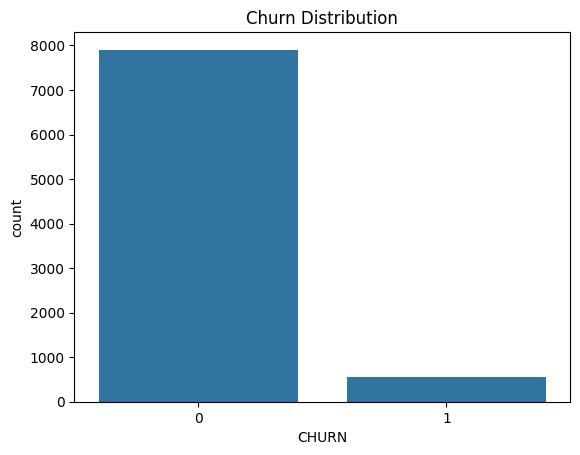

In [9]:
# Exploratory Data Analysis
## Churn Distribution
sns.countplot(x='CHURN', data=data)
plt.title("Churn Distribution")
plt.show()

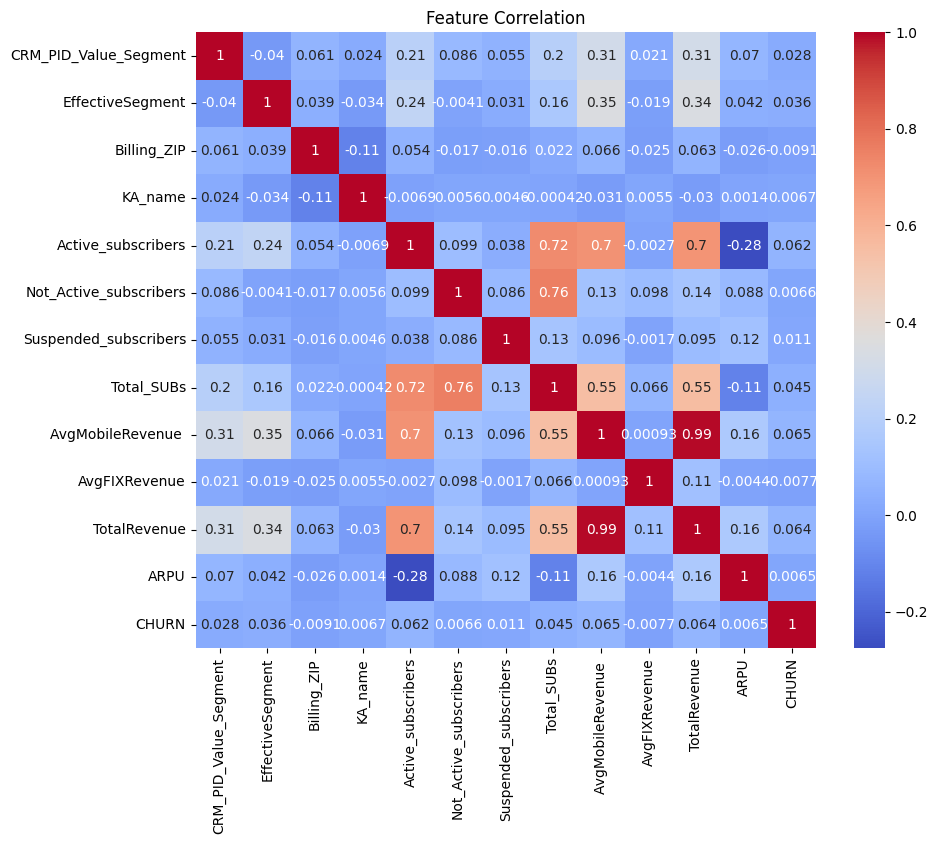

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [11]:
# Feature Selection
X = data.drop('CHURN', axis=1)
y = data['CHURN']

In [12]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:


sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

In [15]:
# Train Machine Learning Models
## Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
## Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [17]:
## Support Vector Machine
svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [18]:
## XGBoost

xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [19]:
## CatBoost Model

cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)

In [20]:
# Model Evaluation Function

def evaluate_model(y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

In [21]:
# Compare Models
## Logistic Regression
print("Logistic Regression")
evaluate_model(y_test, lr_pred)

Logistic Regression
Accuracy: 0.6221170904790065

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.63      0.76      1603
           1       0.07      0.48      0.12        88

    accuracy                           0.62      1691
   macro avg       0.51      0.55      0.44      1691
weighted avg       0.91      0.62      0.73      1691


Confusion Matrix:

[[1010  593]
 [  46   42]]


In [22]:
## Random Forest

print("Random Forest")
evaluate_model(y_test, rf_pred)

Random Forest
Accuracy: 0.9166173861620343

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1603
           1       0.02      0.01      0.01        88

    accuracy                           0.92      1691
   macro avg       0.48      0.49      0.49      1691
weighted avg       0.90      0.92      0.91      1691


Confusion Matrix:

[[1549   54]
 [  87    1]]


In [23]:
## SVM


print("SVM")
evaluate_model(y_test, svm_pred)

SVM
Accuracy: 0.6410408042578356

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.66      0.78      1603
           1       0.06      0.38      0.10        88

    accuracy                           0.64      1691
   macro avg       0.50      0.52      0.44      1691
weighted avg       0.90      0.64      0.74      1691


Confusion Matrix:

[[1051  552]
 [  55   33]]


In [24]:
## XGBoost

print("XGBoost")
evaluate_model(y_test, xgb_pred)

XGBoost
Accuracy: 0.9290360733293909

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1603
           1       0.06      0.02      0.03        88

    accuracy                           0.93      1691
   macro avg       0.50      0.50      0.50      1691
weighted avg       0.90      0.93      0.91      1691


Confusion Matrix:

[[1569   34]
 [  86    2]]


In [25]:
## CatBoost
print("CatBoost")
evaluate_model(y_test, cat_pred)

CatBoost
Accuracy: 0.9390892962743939

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1603
           1       0.06      0.01      0.02        88

    accuracy                           0.94      1691
   macro avg       0.50      0.50      0.49      1691
weighted avg       0.90      0.94      0.92      1691


Confusion Matrix:

[[1587   16]
 [  87    1]]


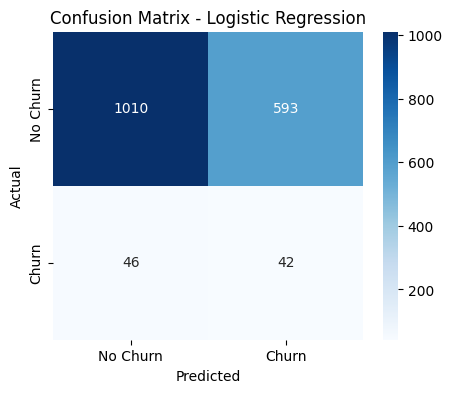

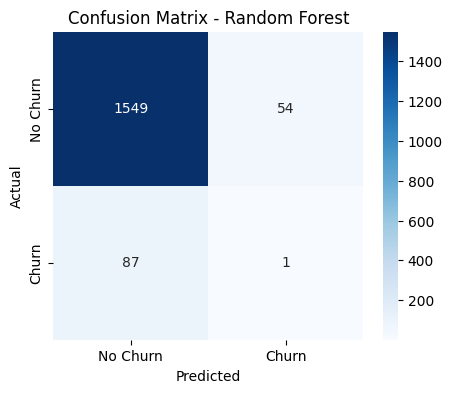

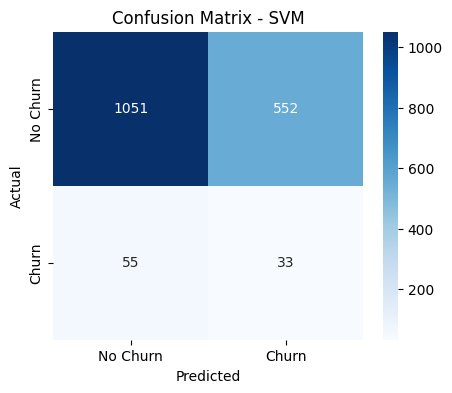

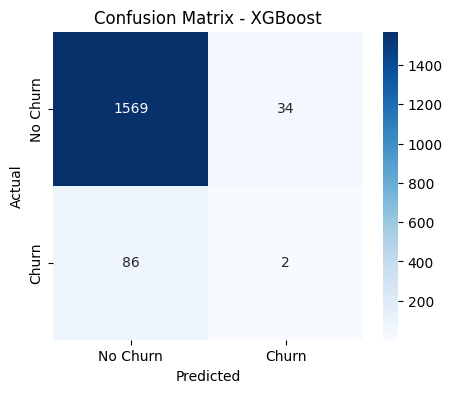

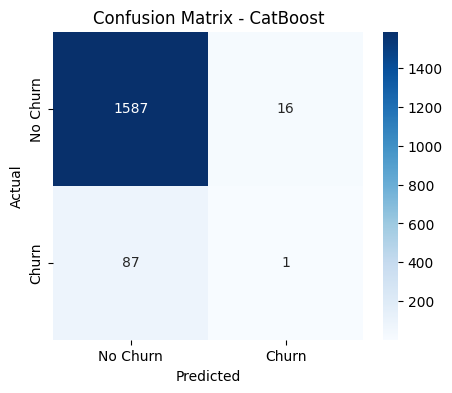

In [26]:
# Confusion Matrix

def plot_confusion_matrix(y_test, y_pred, model_name):

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["No Churn","Churn"],
                yticklabels=["No Churn","Churn"])

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


# Logistic Regression
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression")

# Random Forest
plot_confusion_matrix(y_test, rf_pred, "Random Forest")

# Support Vector Machine
plot_confusion_matrix(y_test, svm_pred, "SVM")

# XGBoost
plot_confusion_matrix(y_test, xgb_pred, "XGBoost")

# CatBoost
plot_confusion_matrix(y_test, cat_pred, "CatBoost")

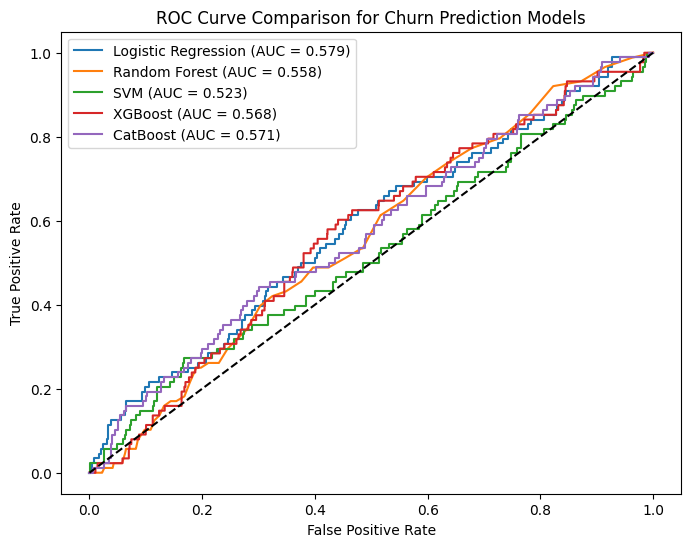

In [27]:
# ROC Curve Plot for All Models

# Get prediction probabilities
lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
svm_probs = svm.predict_proba(X_test)[:,1]
xgb_probs = xgb.predict_proba(X_test)[:,1]
cat_probs = cat.predict_proba(X_test)[:,1]

# Calculate ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)
cat_auc = roc_auc_score(y_test, cat_probs)

# Compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probs)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot(cat_fpr, cat_tpr, label=f'CatBoost (AUC = {cat_auc:.3f})')

# Random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Churn Prediction Models")
plt.legend()
plt.show()

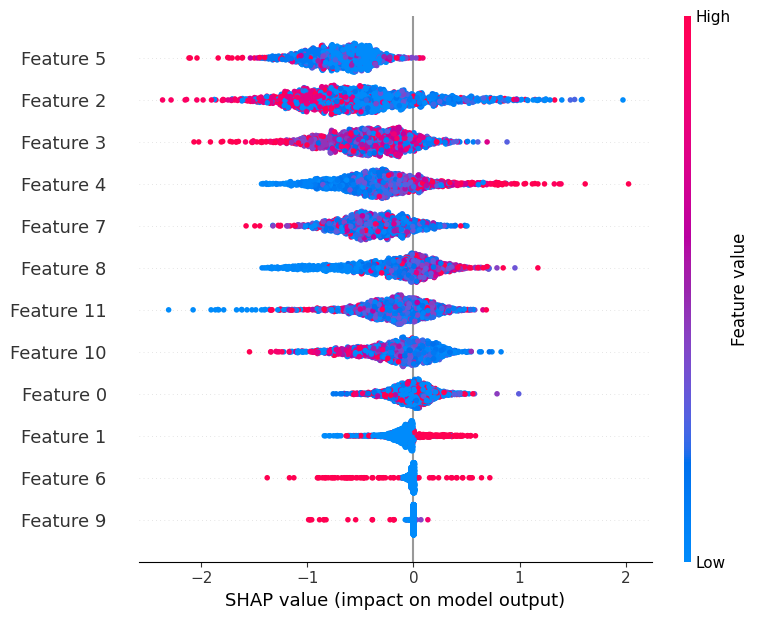

In [28]:


# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

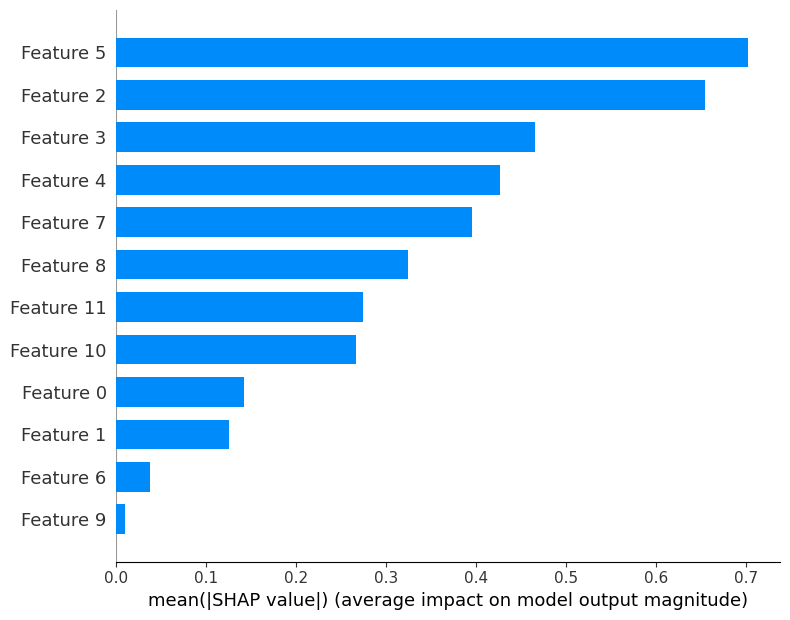

In [29]:
shap.summary_plot(shap_values, X_test, plot_type="bar")